# Создание датасета из API GitHub и его анализ

Практическая работа № 4 по дисциплине «Методы машинного обучения».
Московский Политех, группа 231-329, Арутюнян Ф. Р.

**Как я понял задачу.** Работа парная к лабораторной № 5, где датасет собирался из API Hacker News.
Здесь источник другой, API поиска GitHub. Работа компактнее лабораторной, с упором на процесс сбора.

**Почему поиск, а не лента событий.** Сначала я проверил ленту публичных событий `api.github.com/events`:
без авторизации она кешируется (заголовок `X-Poll-Interval: 60`, два запроса с разницей 8 секунд вернули
одни и те же 100 событий) и отдаёт не больше 300 событий. Датасет из неё не собрать. API поиска
репозиториев работает без авторизации, отдаёт по 100 репозиториев за запрос и умеет отбирать
репозитории по дате создания и числу звёзд.

**Как устроена выборка.** Первая версия брала только 100 самых популярных репозиториев каждого дня,
и выборка оказалась обрезана снизу: меньше 49 звёзд в неё не попадало, а задача «выше или ниже медианы»
сводилась к сравнению уже популярных проектов между собой (ROC-AUC 0,57). Поэтому выборка двухслойная:
за каждый день с 1 по 15 августа 2025 года беру 100 самых популярных репозиториев и 100 обычных,
у которых от 1 до 3 звёзд. Год назад, чтобы число звёзд успело устояться.

**Что собираю:** дата создания и последнего изменения, язык, размер, лицензия, описание, темы,
тип владельца, звёзды, форки, открытые задачи.

**План:**
1. Сбор сырых данных через API.
2. Разбор в таблицу и очистка.
3. Разведочный анализ: чем популярные репозитории отличаются от обычных.
4. Сохранение в csv.
5. Демонстрация пригодности: модель отличает популярный репозиторий от обычного.

## 0. Библиотеки и настройки

In [1]:
import os
import json
import time
import urllib.request
from datetime import date, timedelta

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100
os.makedirs('figures', exist_ok=True)
os.makedirs('data', exist_ok=True)
RANDOM_STATE = 42


def save_fig(name):
    plt.savefig(os.path.join('figures', name), dpi=150, bbox_inches='tight')

## 1. Сбор сырых данных

Для каждого дня два запроса: `created:ДАТА` с сортировкой по звёздам и `created:ДАТА stars:1..3`.
Без авторизации API поиска разрешает 10 запросов в минуту, поэтому между запросами пауза 7 секунд,
весь сбор занимает около трёх с половиной минут. Сырые ответы сохраняются в `data/raw_github_repos.json`,
при повторном запуске данные берутся из файла.

In [2]:
API = 'https://api.github.com/search/repositories'
RAW = 'data/raw_github_repos.json'
DAYS = [date(2025, 8, 1) + timedelta(days=i) for i in range(15)]
QUERIES = {'popular': 'created:{d}&sort=stars&order=desc', 'ordinary': 'created:{d}+stars:1..3'}


def search(query):
    req = urllib.request.Request(f'{API}?q={query}&per_page=100',
                                 headers={'User-Agent': 'mospolytech-ml-coursework',
                                          'Accept': 'application/vnd.github+json'})
    with urllib.request.urlopen(req, timeout=60) as r:
        return json.load(r)


if os.path.exists(RAW):
    raw = json.load(open(RAW, encoding='utf-8'))
    print('Сырые данные взяты из файла')
else:
    raw = {'collected_at': int(time.time()), 'items': []}
    for day in DAYS:
        for group, q in QUERIES.items():
            resp = search(q.format(d=day.isoformat()))
            for it in resp['items']:
                it['_group'] = group
            raw['items'] += resp['items']
            print(f"{day} {group:8}: найдено {resp['total_count']:>6}, получено {len(resp['items'])}")
            time.sleep(7)
    json.dump(raw, open(RAW, 'w', encoding='utf-8'))

print('Репозиториев в сыром ответе:', len(raw['items']))
print('Полей в одной записи:', len(raw['items'][0]))

2025-08-01 popular : найдено 160491, получено 100


2025-08-01 ordinary: найдено   9888, получено 100


2025-08-02 popular : найдено 137177, получено 100


2025-08-02 ordinary: найдено   9228, получено 100


2025-08-03 popular : найдено 133353, получено 100


...

2025-08-14 popular : найдено 170838, получено 100


2025-08-14 ordinary: найдено  10032, получено 100


2025-08-15 popular : найдено 152143, получено 100


2025-08-15 ordinary: найдено   9453, получено 100


Репозиториев в сыром ответе: 3000
Полей в одной записи: 83


## 2. Разбор и очистка

В сырой записи 82 поля, большинство это ссылки на другие методы API. Беру содержательные.
Имена репозиториев и владельцев в датасет не кладу, достаточно числового идентификатора.

In [3]:
collected = pd.Timestamp(raw['collected_at'], unit='s', tz='UTC')
rows = []
for it in raw['items']:
    rows.append({
        'id': it['id'],
        'group': it['_group'],
        'created_at': it['created_at'],
        'pushed_at': it['pushed_at'],
        'language': it['language'] or 'не указан',
        'size_kb': it['size'],
        'stars': it['stargazers_count'],
        'forks': it['forks_count'],
        'open_issues': it['open_issues_count'],
        'has_license': it['license'] is not None,
        'desc_len': len(it['description'] or ''),
        'topics': len(it.get('topics') or []),
        'owner_org': it['owner']['type'] == 'Organization',
        'has_pages': it['has_pages'],
    })

df = pd.DataFrame(rows)
df['created_at'] = pd.to_datetime(df['created_at'], utc=True)
df['pushed_at'] = pd.to_datetime(df['pushed_at'], utc=True)
df['active_days'] = (df['pushed_at'] - df['created_at']).dt.days

print('Строк:', len(df), '| дубликатов по id:', int(df['id'].duplicated().sum()), '| пропусков:', int(df.isna().sum().sum()))
print('Пустых репозиториев (размер 0):', int((df['size_kb'] == 0).sum()))
print('Последнее изменение раньше создания:', int((df['active_days'] < 0).sum()),
      '(история перенесена из другого места)')

before = len(df)
df = df.drop_duplicates('id')
df = df[df['size_kb'] > 0].copy()
df['active_days'] = df['active_days'].clip(lower=0)
print(f'После очистки: {len(df)} репозиториев, удалено {before - len(df)}')
print(df.groupby('group')['stars'].describe()[['min', '50%', 'max']])

Строк: 3000 | дубликатов по id: 0 | пропусков: 0
Пустых репозиториев (размер 0): 22
Последнее изменение раньше создания: 3 (история перенесена из другого места)
После очистки: 2978 репозиториев, удалено 22
           min    50%       max
group                          
ordinary   3.0    3.0       3.0
popular   49.0  147.5  138009.0


## 3. Разведочный анализ

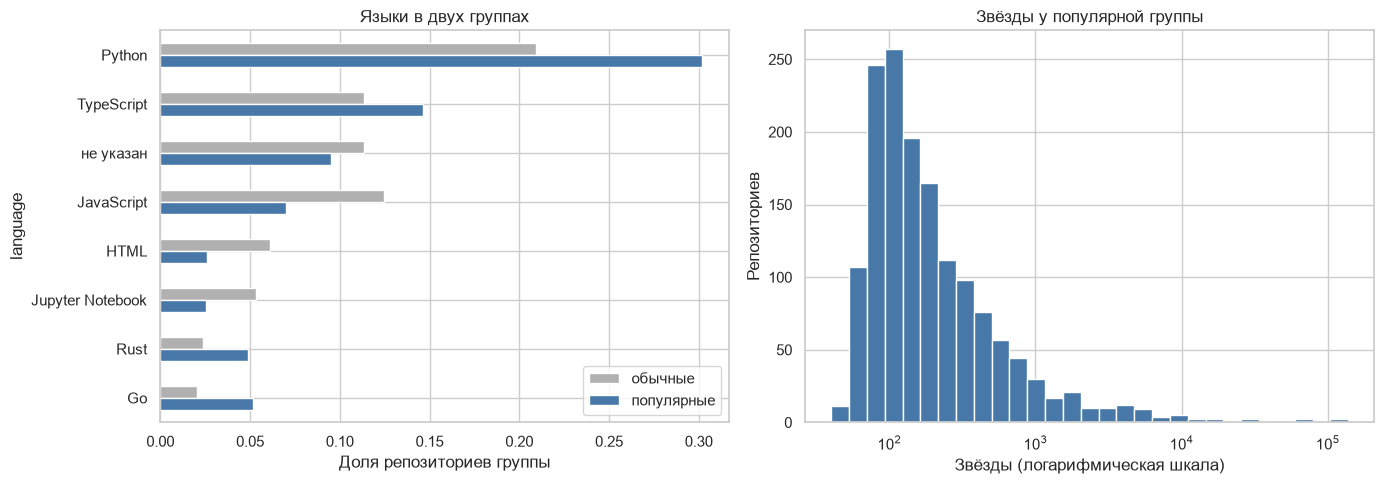

group             ordinary  popular
language                           
Python               0.209    0.302
TypeScript           0.114    0.146
не указан            0.114    0.095
JavaScript           0.124    0.070
HTML                 0.061    0.026
Jupyter Notebook     0.053    0.025
Rust                 0.024    0.049
Go                   0.020    0.051
Популярные: медиана звёзд 147 | максимум 138009


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
top_langs = df['language'].value_counts().head(8).index
share = (df[df['language'].isin(top_langs)].groupby(['language', 'group']).size()
         .unstack(fill_value=0) / df.groupby('group').size())
share.loc[top_langs].plot.barh(ax=axes[0], color={'popular': '#4878a8', 'ordinary': '#b0b0b0'})
axes[0].invert_yaxis()
axes[0].set_xlabel('Доля репозиториев группы')
axes[0].set_title('Языки в двух группах')
axes[0].legend(['обычные', 'популярные'])

axes[1].hist(df.loc[df['group'] == 'popular', 'stars'],
             bins=np.logspace(np.log10(40), np.log10(df['stars'].max() + 1), 30), color='#4878a8')
axes[1].set_xscale('log')
axes[1].set_xlabel('Звёзды (логарифмическая шкала)')
axes[1].set_ylabel('Репозиториев')
axes[1].set_title('Звёзды у популярной группы')
fig.tight_layout()
save_fig('01_languages_stars.png')
plt.show()

print(share.loc[top_langs].round(3))
pop = df[df['group'] == 'popular']
print('Популярные: медиана звёзд', int(pop['stars'].median()), '| максимум', int(pop['stars'].max()))

**Рисунок 1 — Языки в двух группах и распределение звёзд у популярных**

Среди популярных больше Python (30,2 % против 20,9 %), Rust и Go, среди обычных больше JavaScript, HTML и ноутбуков Jupyter; звёзды у популярной группы от 49 до 138 009, медиана 147.

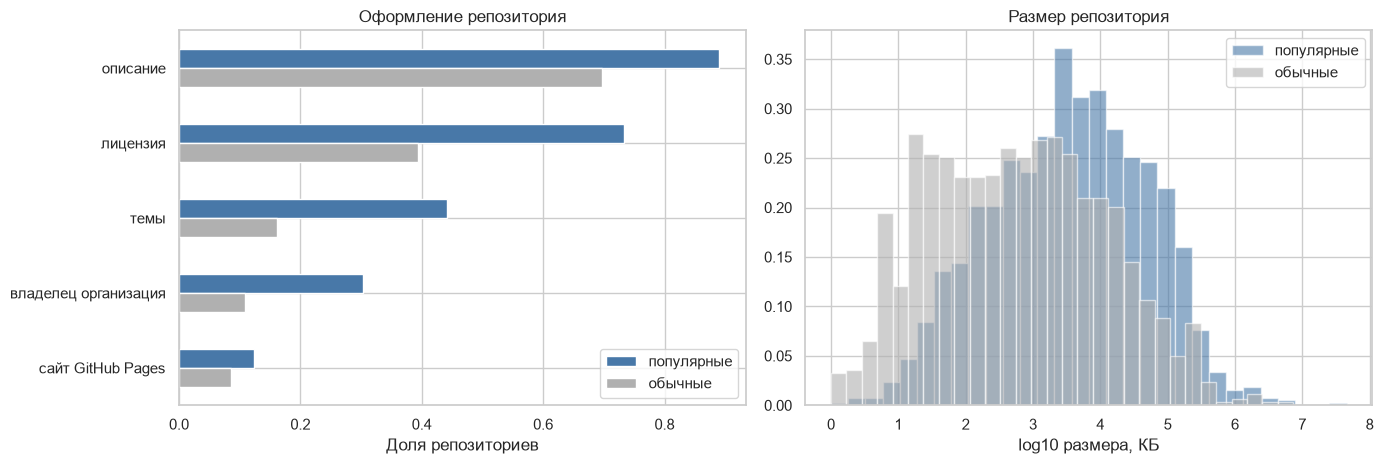

group                 popular  ordinary
описание                0.890     0.697
лицензия                0.734     0.394
темы                    0.441     0.162
владелец организация    0.303     0.109
сайт GitHub Pages       0.123     0.086
Медиана размера, КБ: {'ordinary': 560.5, 'popular': 3667.0}


In [5]:
df['has_desc'] = df['desc_len'] > 0
df['has_topics'] = df['topics'] > 0
cols = {'has_desc': 'описание', 'has_license': 'лицензия', 'has_topics': 'темы',
        'owner_org': 'владелец организация', 'has_pages': 'сайт GitHub Pages'}
flags = df.groupby('group')[list(cols)].mean().T.rename(index=cols)[['popular', 'ordinary']]

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
flags.plot.barh(ax=axes[0], color=['#4878a8', '#b0b0b0'])
axes[0].invert_yaxis()
axes[0].set_xlabel('Доля репозиториев')
axes[0].set_title('Оформление репозитория')
axes[0].legend(['популярные', 'обычные'])

for group, color, name in [('popular', '#4878a8', 'популярные'), ('ordinary', '#b0b0b0', 'обычные')]:
    axes[1].hist(np.log10(df.loc[df['group'] == group, 'size_kb']), bins=30, alpha=0.6, color=color,
                 label=name, density=True)
axes[1].set_xlabel('log10 размера, КБ')
axes[1].set_title('Размер репозитория')
axes[1].legend()
fig.tight_layout()
save_fig('02_features.png')
plt.show()

print(flags.round(3))
print('Медиана размера, КБ:', df.groupby('group')['size_kb'].median().to_dict())

**Рисунок 2 — Оформление и размер популярных и обычных репозиториев**

Популярные репозитории заметно лучше оформлены: лицензия у 73,4 % против 39,4 %, темы у 44,1 % против 16,2 %, владелец организация у 30,3 % против 10,9 %, а медианный размер в 6,5 раза больше (3667 КБ против 561).

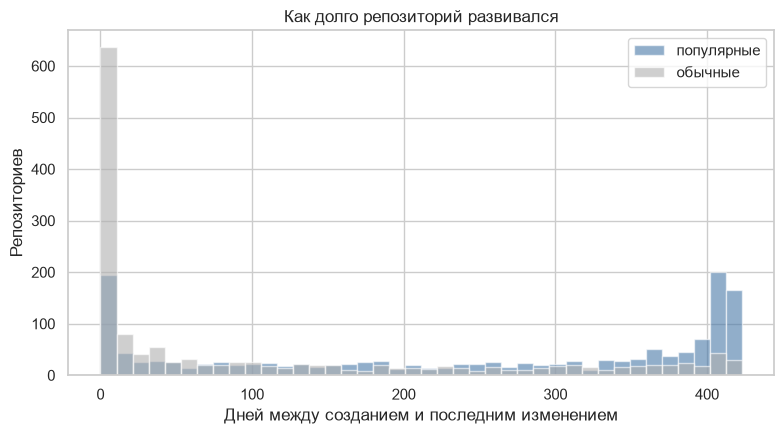

{'ordinary': 27.0, 'popular': 281.0}
Заброшены в первую неделю: {'ordinary': 0.405, 'popular': 0.117}


In [6]:
fig, ax = plt.subplots(figsize=(8, 4.5))
for group, color, name in [('popular', '#4878a8', 'популярные'), ('ordinary', '#b0b0b0', 'обычные')]:
    ax.hist(df.loc[df['group'] == group, 'active_days'], bins=40, alpha=0.6, color=color, label=name)
ax.set_xlabel('Дней между созданием и последним изменением')
ax.set_ylabel('Репозиториев')
ax.set_title('Как долго репозиторий развивался')
ax.legend()
fig.tight_layout()
save_fig('03_active_days.png')
plt.show()

print(df.groupby('group')['active_days'].median().to_dict())
print('Заброшены в первую неделю:', (df.assign(w=df['active_days'] <= 7).groupby('group')['w'].mean().round(3)).to_dict())

**Рисунок 3 — Срок развития репозиториев в двух группах**

Популярные развиваются дольше: медиана 281 день против 27, а в первую же неделю забрасывают 40,5 % обычных репозиториев и только 11,7 % популярных.

## 4. Сохранение датасета

In [7]:
dataset = df.drop(columns=['has_desc', 'has_topics']).sort_values('created_at').reset_index(drop=True)
dataset.to_csv('data/github_repos.csv', index=False)
print('Строк:', len(dataset), '| столбцов:', dataset.shape[1],
      '| размер:', round(os.path.getsize('data/github_repos.csv') / 1024, 1), 'КБ')

Строк: 2978 | столбцов: 15 | размер: 342.7 КБ


## 5. Демонстрация пригодности датасета

Задача: по свойствам репозитория отличить популярный от обычного. Звёзды, форки и открытые задачи
в признаки не беру: это следствие популярности, с ними модель просто подсмотрела бы ответ.
Признаки: размер, длина описания, число тем, лицензия, тип владельца, сайт, срок развития и язык.

In [8]:
data = dataset.copy()
y = (data['group'] == 'popular').astype(int)
langs = data['language'].value_counts().head(8).index
X = pd.DataFrame({
    'log_size': np.log1p(data['size_kb']),
    'desc_len': data['desc_len'],
    'topics': data['topics'],
    'has_license': data['has_license'].astype(int),
    'owner_org': data['owner_org'].astype(int),
    'has_pages': data['has_pages'].astype(int),
    'active_days': data['active_days'],
})
for lang in langs:
    X[f'lang_{lang}'] = (data['language'] == lang).astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE)
scaler = StandardScaler().fit(X_train)
logreg = LogisticRegression(max_iter=2000).fit(scaler.transform(X_train), y_train)
rf = RandomForestClassifier(n_estimators=300, min_samples_leaf=5, random_state=RANDOM_STATE,
                            n_jobs=-1).fit(X_train, y_train)

rows = []
for name, m, Xt in [('Логистическая регрессия', logreg, scaler.transform(X_test)), ('Случайный лес', rf, X_test)]:
    p = m.predict_proba(Xt)[:, 1]
    rows.append({'Модель': name, 'Accuracy': accuracy_score(y_test, (p > 0.5).astype(int)),
                 'ROC-AUC': roc_auc_score(y_test, p)})
print(pd.DataFrame(rows).set_index('Модель').round(4))
print()
print(classification_report(y_test, rf.predict(X_test), target_names=['обычный', 'популярный'], digits=4))

                         Accuracy  ROC-AUC
Модель                                    
Логистическая регрессия    0.7060   0.7782
Случайный лес              0.7208   0.7994

              precision    recall  f1-score   support

     обычный     0.7098    0.7405    0.7249       370
  популярный     0.7326    0.7013    0.7166       375

    accuracy                         0.7208       745
   macro avg     0.7212    0.7209    0.7207       745
weighted avg     0.7213    0.7208    0.7207       745



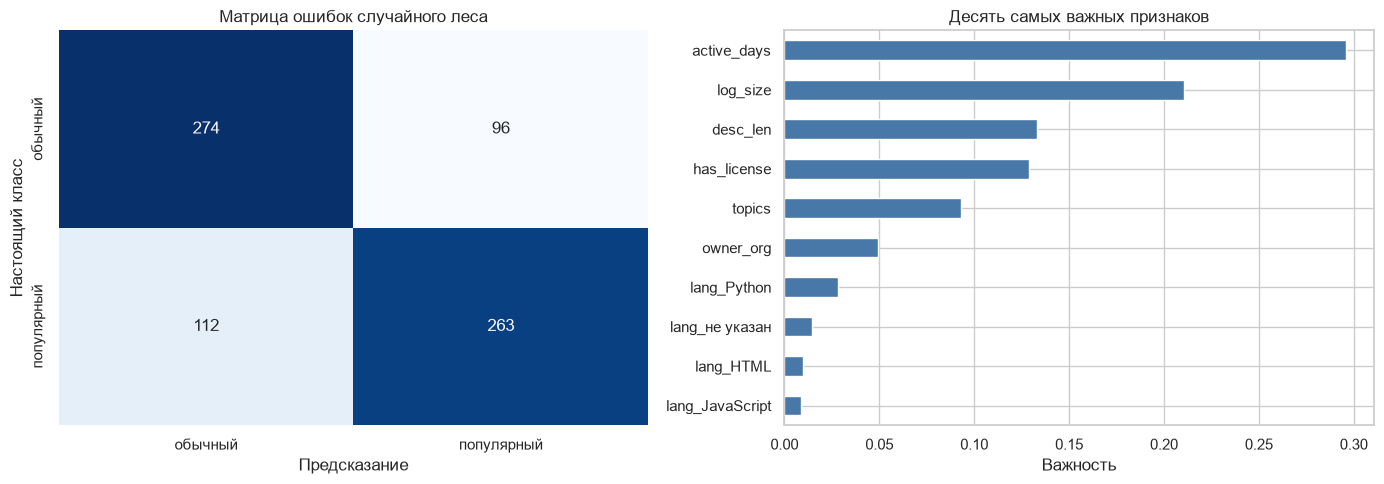

{'active_days': 0.296, 'log_size': 0.211, 'desc_len': 0.133, 'has_license': 0.129, 'topics': 0.093, 'owner_org': 0.049, 'lang_Python': 0.028, 'lang_не указан': 0.014, 'lang_HTML': 0.01, 'lang_JavaScript': 0.009}


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cm = confusion_matrix(y_test, rf.predict(X_test))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['обычный', 'популярный'], yticklabels=['обычный', 'популярный'], ax=axes[0])
axes[0].set_xlabel('Предсказание')
axes[0].set_ylabel('Настоящий класс')
axes[0].set_title('Матрица ошибок случайного леса')

imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values().tail(10)
imp.plot.barh(ax=axes[1], color='#4878a8')
axes[1].set_xlabel('Важность')
axes[1].set_title('Десять самых важных признаков')
fig.tight_layout()
save_fig('04_model.png')
plt.show()
print(imp.sort_values(ascending=False).round(3).to_dict())

**Рисунок 4 — Популярный или обычный репозиторий: матрица ошибок и важность признаков**

Лес отличает популярный репозиторий от обычного с accuracy 0,7208 и ROC-AUC 0,7994, главные признаки срок развития (0,296), размер (0,211), длина описания (0,133) и лицензия (0,129).

## 6. Выводы

1. **Сбор.** Через открытый API поиска GitHub без авторизации сделано 30 запросов с паузой 7 секунд:
   за каждый день с 1 по 15 августа 2025 года 100 самых популярных репозиториев и 100 обычных.
   Сырой ответ сохранён в `data/raw_github_repos.json`. Запрос `stars:1..3` вернул репозитории ровно
   с тремя звёздами: сортировка по совпадению ставит их первыми. Лента событий `api.github.com/events`
   для датасета не подошла, без авторизации она кешируется и отдаёт не больше 300 событий.

2. **Датасет.** Из 82 полей сырой записи взяты 15 содержательных. Удалено 22 пустых репозитория,
   у 3 репозиториев последнее изменение раньше создания (история перенесена извне), срок развития
   у них обрезан до нуля. Итог `data/github_repos.csv`: 2978 репозиториев, 343 КБ, без имён.

3. **Что показал анализ.** Популярные репозитории лучше оформлены: лицензия у 73,4 % против 39,4 %,
   темы у 44,1 % против 16,2 %, чаще принадлежат организациям (30,3 % против 10,9 %), в 6,5 раза больше
   по размеру и развиваются дольше (медиана 281 день против 27). Среди популярных больше Python,
   Rust и Go, среди обычных больше JavaScript, HTML и ноутбуков Jupyter.

4. **Модель.** Случайный лес отличает популярный репозиторий от обычного с accuracy 0,7208
   и ROC-AUC 0,7994, логистическая регрессия 0,7060 и 0,7782. Звёзды, форки и задачи в признаки
   не входили. Оговорка: срок развития, самый важный признак (0,296), отчасти следствие популярности,
   популярный проект чаще продолжают поддерживать.

5. **Урок по выборке.** Первая версия брала только популярные репозитории, и модель внутри этой
   обрезанной выборки давала ROC-AUC 0,57. Двухслойная выборка превратила задачу в осмысленную:
   чем популярные проекты отличаются от обычных.